In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

In [2]:
# load shatterseek CGRs
shatterseek = pd.read_csv('../../../Shatterseek/results/complex_genomic_rearrangements.csv')
shatterseek = shatterseek[['chrom','start', 'end', 'sample_id', 'inter_other_chroms_coords_all', 'is_chromothripsis']]
shatterseek['chrom'] = shatterseek['chrom'].astype(str)
final_samples = pd.read_csv('../../../SV_sample_data/data/final_samples.csv')
shatterseek = shatterseek[shatterseek['sample_id'].isin(final_samples['tumor_normal_pair'])]
shatterseek.head()

,chrom,start,end,sample_id,inter_other_chroms_coords_all,is_chromothripsis
0,4,11951412.0,55566727.0,09T02-09N01,10:9688716-13319180;,True
1,7,107383128.0,121384850.0,09T02-09N01,,True
2,8,46121386.0,119425527.0,09T02-09N01,16:56625608-70807667;,True
3,11,10721274.0,32356630.0,09T02-09N01,8:46121386-119425527;,True
4,19,7521223.0,14737502.0,09T02-09N01,8:46121386-119425527;,False


In [3]:
# load clustered SV events
clustered_sv = pd.read_csv('../results/merged_clustered_sv_events.csv')
clustered_sv = clustered_sv[['chr', 'start', 'end', 'sample', 'event_id']]
clustered_sv['chr'] = clustered_sv['chr'].astype(str).replace({'23': 'X', '24': 'Y'})
clustered_sv.head()

,chr,start,end,sample,event_id
0,11,25810096,32598616,09T02-09N01,09T02-09N01_11_25810096_32598616
1,19,9538321,11079287,09T02-09N01,09T02-09N01_19_9538321_11079287
2,19,56370219,57632870,09T02-09N01,09T02-09N01_19_56370219_57632870
3,21,23813478,25252996,09T02-09N01,09T02-09N01_21_23813478_25252996
4,3,116621819,117141088,09T02-09N01,09T02-09N01_3_116621819_117141088


In [4]:
# add columns to shatterseek: clustered_sv_overlap, num_clustered_sv_overlap, inter_clustered_sv_overlap, num_inter_clustered_sv_overlap
def intervals_overlap(s1, e1, s2, e2):
    return max(s1, s2) < min(e1, e2)

# To parse the inter_other_chroms_coords_all column (chr:start-end;chr:start-end...)
def parse_inter_coords(s):
    if pd.isna(s) or not str(s).strip():
        return []
    out = []
    for part in str(s).split(';'):
        part = part.strip()
        if not part:
            continue
        try:
            chrom, rest = part.split(':', 1)
            start, end = rest.split('-')
            out.append((str(chrom).strip(), int(float(start)), int(float(end))))
        except (ValueError, AttributeError):
            continue
    return out

In [5]:
def find_overlapping_clusters(row, clustered_df):
    sample = row['sample_id']
    cv = clustered_df[clustered_df['sample'] == sample]
    if cv.empty:
        return [], 0, [], 0

    chrom, start, end = row['chrom'], row['start'], row['end']
    main_overlap_ids = []
    for _, r in cv.iterrows():
        if r['chr'] != chrom:
            continue
        if intervals_overlap(start, end, r['start'], r['end']):
            main_overlap_ids.append(r['event_id'])

    # Inter-chrom regions
    inter_regions = parse_inter_coords(row.get('inter_other_chroms_coords_all'))
    inter_overlap_ids = []
    for ichr, istart, iend in inter_regions:
        for _, r in cv.iterrows():
            if r['chr'] != str(ichr):
                continue
            if intervals_overlap(istart, iend, r['start'], r['end']):
                inter_overlap_ids.append(r['event_id'])

    # Deduplicate inter overlaps per event
    inter_overlap_ids = list(dict.fromkeys(inter_overlap_ids))

    return (main_overlap_ids, len(main_overlap_ids), inter_overlap_ids, len(inter_overlap_ids))

# Apply to each row
out = shatterseek.apply(
    lambda r: find_overlapping_clusters(r, clustered_sv), axis=1
)
shatterseek['clustered_sv_overlap'] = [x[0] for x in out]
shatterseek['num_clustered_sv_overlap'] = [x[1] for x in out]
shatterseek['inter_clustered_sv_overlap'] = [x[2] for x in out]
shatterseek['num_inter_clustered_sv_overlap'] = [x[3] for x in out]

shatterseek.to_csv('../results/shatterseek_clustered_sv_overlap.csv', index=False)
shatterseek.head()

,chrom,start,end,sample_id,inter_other_chroms_coords_all,is_chromothripsis,clustered_sv_overlap,num_clustered_sv_overlap,inter_clustered_sv_overlap,num_inter_clustered_sv_overlap
0,4,11951412.0,55566727.0,09T02-09N01,10:9688716-13319180;,True,[09T02-09N01_4_13471388_34040322],1,[],0
1,7,107383128.0,121384850.0,09T02-09N01,,True,[],0,[],0
2,8,46121386.0,119425527.0,09T02-09N01,16:56625608-70807667;,True,"[09T02-09N01_8_54141094_54269718, 09T02-09N01_...",2,[],0
3,11,10721274.0,32356630.0,09T02-09N01,8:46121386-119425527;,True,[09T02-09N01_11_25810096_32598616],1,"[09T02-09N01_8_54141094_54269718, 09T02-09N01_...",2
4,19,7521223.0,14737502.0,09T02-09N01,8:46121386-119425527;,False,[09T02-09N01_19_9538321_11079287],1,"[09T02-09N01_8_54141094_54269718, 09T02-09N01_...",2


In [6]:
# how many shatterseek events have no clustered sv overlap?
shatterseek_no_overlap = shatterseek[shatterseek['num_clustered_sv_overlap'] == 0]
shatterseek_overlap = shatterseek[shatterseek['num_clustered_sv_overlap'] > 0]

print(f"Number of shatterseek events with no clustered sv overlap: {len(shatterseek_no_overlap)}")
print("Percentage:", len(shatterseek_no_overlap)/len(shatterseek) * 100)

print(f"Number of shatterseek events with clustered sv overlap: {len(shatterseek_overlap)}")
print(shatterseek_overlap['num_clustered_sv_overlap'].value_counts())

Number of shatterseek events with no clustered sv overlap: 384
Percentage: 36.329233680227055
Number of shatterseek events with clustered sv overlap: 673
num_clustered_sv_overlap
1    564
2     85
3     17
4      6
5      1
Name: count, dtype: int64


In [7]:
# add columns to clustered_sv: shatterseek_overlap, is_chromothripsis
# shatterseek_overlap: True if the clustered sv is in "clustered_sv_overlap" column for any shatterseek event
# is_chromothripsis: True if the clustered sv overlaps a shatterseek event that is chromothripsis

# only include the samples that shatterseek ran on
shatterseek_samples = pd.read_csv('../../../Shatterseek/data/shatterseek_sv_data.csv')
shatterseek_samples = shatterseek_samples['sample_id'].unique()
shatterseek_samples = shatterseek_samples.tolist()
print("Number of samples that shatterseek ran on:", len(shatterseek_samples))
clustered_sv = clustered_sv[clustered_sv['sample'].isin(shatterseek_samples)]

def add_shatterseek_columns(row):
    cid = row['event_id']
    sample = row['sample']
    ss = shatterseek[shatterseek['sample_id'] == sample]
    if ss.empty:
        return pd.Series({'shatterseek_overlap': False, 'is_chromothripsis': False})

    in_main = ss['clustered_sv_overlap'].apply(lambda L: cid in L if isinstance(L, list) else False)
    matching = ss[in_main]
    n = len(matching)
    is_ct = matching['is_chromothripsis'].any() if n > 0 else False

    return pd.Series({
        'shatterseek_overlap': n > 0,
        'is_chromothripsis': is_ct,
    })

clustered_sv[['shatterseek_overlap', 'is_chromothripsis']] = (clustered_sv.apply(add_shatterseek_columns, axis=1))
print(clustered_sv['shatterseek_overlap'].value_counts())
print(clustered_sv['is_chromothripsis'].value_counts())
clustered_sv.head()

Number of samples that shatterseek ran on: 228
shatterseek_overlap
True     814
False    331
Name: count, dtype: int64
is_chromothripsis
False    659
True     486
Name: count, dtype: int64


,chr,start,end,sample,event_id,shatterseek_overlap,is_chromothripsis
0,11,25810096,32598616,09T02-09N01,09T02-09N01_11_25810096_32598616,True,True
1,19,9538321,11079287,09T02-09N01,09T02-09N01_19_9538321_11079287,True,False
2,19,56370219,57632870,09T02-09N01,09T02-09N01_19_56370219_57632870,False,False
3,21,23813478,25252996,09T02-09N01,09T02-09N01_21_23813478_25252996,True,False
4,3,116621819,117141088,09T02-09N01,09T02-09N01_3_116621819_117141088,False,False


In [8]:
events_df = pd.read_csv('../results/hotspot_event_definitions.csv')
events = (
    events_df
    .set_index('event')[['chrom', 'start', 'end']]
    .to_dict(orient='index')
)

matrix = pd.read_csv("../results/clustered_sv_merged_hotspot_matrix.csv")
matrix = matrix[matrix['sample_id'].isin(shatterseek_samples)]
matrix.head()

,sample_id,CCND3,MYC,CDK4-MDM2,CCNE1,TP53,n_clustered_regions
0,09T02-09N01,0,1,0,0,0,8
1,09T03-09N01,0,0,0,0,0,4
2,10T03-10N02,0,0,0,0,0,2
3,13T02-13N02,0,0,1,1,0,8
4,17_439_00067_T2-17_439_00067_WB,0,0,0,0,0,3


In [9]:
# Hotspot columns in the matrix (without _shatterseek)
hotspot_cols = ['CCND3', 'MYC', 'CDK4-MDM2', 'CCNE1', 'TP53']

def sample_has_shatterseek_in_hotspot(sample_id, hotspot_name, shatterseek_df, events_dict):
    region = events_dict.get(hotspot_name)
    chrom_r, start_r, end_r = str(region['chrom']), region['start'], region['end']
    ss = shatterseek_df[shatterseek_df['sample_id'] == sample_id]
    for _, row in ss.iterrows():
        if str(row['chrom']) != chrom_r:
            continue
        if intervals_overlap(row['start'], row['end'], start_r, end_r):
            return True
    return False

# Add ShatterSeek-overlap columns 
for col in hotspot_cols:
    new_col = f"{col}_shatterseek"
    matrix[new_col] = matrix['sample_id'].apply(
        lambda sid: 1 if sample_has_shatterseek_in_hotspot(sid, col, shatterseek, events) else 0
    )

matrix.head()

,sample_id,CCND3,MYC,CDK4-MDM2,CCNE1,TP53,n_clustered_regions,CCND3_shatterseek,MYC_shatterseek,CDK4-MDM2_shatterseek,CCNE1_shatterseek,TP53_shatterseek
0,09T02-09N01,0,1,0,0,0,8,0,1,0,0,0
1,09T03-09N01,0,0,0,0,0,4,0,0,0,0,0
2,10T03-10N02,0,0,0,0,0,2,0,0,0,0,0
3,13T02-13N02,0,0,1,1,0,8,1,0,1,0,0
4,17_439_00067_T2-17_439_00067_WB,0,0,0,0,0,3,0,0,1,1,0


In [10]:
for col in hotspot_cols:
    n = ((matrix[col] > 0) & (matrix[f'{col}_shatterseek'] > 0)).sum()
    print(f"{n} samples with both clustered SV and Shatterseek CGR for {col}")
    print(f"{((matrix[col] > 0) & (matrix[f'{col}_shatterseek'] == 0)).sum()} samples with only clustered SV for {col}")
    print(f"{((matrix[col] == 0) & (matrix[f'{col}_shatterseek'] > 0)).sum()} samples with only Shatterseek CGR for {col}")
    print()

matrix.to_csv('../results/clustered_sv_shatterseek_hotspot_matrix.csv', index=False)

39 samples with both clustered SV and Shatterseek CGR for CCND3
2 samples with only clustered SV for CCND3
19 samples with only Shatterseek CGR for CCND3

37 samples with both clustered SV and Shatterseek CGR for MYC
6 samples with only clustered SV for MYC
23 samples with only Shatterseek CGR for MYC

22 samples with both clustered SV and Shatterseek CGR for CDK4-MDM2
2 samples with only clustered SV for CDK4-MDM2
15 samples with only Shatterseek CGR for CDK4-MDM2

20 samples with both clustered SV and Shatterseek CGR for CCNE1
17 samples with only clustered SV for CCNE1
17 samples with only Shatterseek CGR for CCNE1

40 samples with both clustered SV and Shatterseek CGR for TP53
18 samples with only clustered SV for TP53
13 samples with only Shatterseek CGR for TP53



In [11]:
# For the clustered sv hotspot events, how many of these are chromothripsis? involve ecDNA formation? both? (filter to analysis samples)
analysis_samples = pd.read_csv('../../../SV_sample_data/data/final_analysis_samples.csv')
ecDNA_matrix = pd.read_csv('../../../CNAs_Amplicon_Architect/results/ecDNA_matrix.csv', index_col=0)
clustered_sv_matrix = pd.read_csv('../results/clustered_sv_merged_hotspot_matrix.csv')
clustered_sv_matrix = clustered_sv_matrix[clustered_sv_matrix['sample_id'].isin(analysis_samples['tumor_normal_pair'])]

# Columns to pull from ecDNA
ecdna_cols = [
    'tumor_normal_pair',
    'ecDNA_CCND3',
    'ecDNA_MYC',
    'ecDNA_CDK4-MDM2',
    'ecDNA_CCNE1',
    'ecDNA_TP53',
]
ecdna_subset = ecDNA_matrix[ecdna_cols].copy()

# merge clustered sv matrix with ecDNA matrix
matrix_base = clustered_sv_matrix.merge(
    ecdna_subset,
    left_on='sample_id',
    right_on='tumor_normal_pair',
    how='inner',
)

matrix_base = matrix_base.drop(columns=['tumor_normal_pair'])

# Filter shatterseek df to only include chromothripsis events
shatterseek_chromothripsis = shatterseek[shatterseek['is_chromothripsis'] == True]
# Add ShatterSeek-overlap columns 
for col in hotspot_cols:
    new_col = f"{col}_chromothripsis"
    matrix_base[new_col] = matrix_base['sample_id'].apply(
        lambda sid: 1 if sample_has_shatterseek_in_hotspot(sid, col, shatterseek_chromothripsis, events) else 0
    )
print("Total number of samples:", len(matrix_base))
matrix_base.head()

Total number of samples: 166


,sample_id,CCND3,MYC,CDK4-MDM2,CCNE1,TP53,n_clustered_regions,ecDNA_CCND3,ecDNA_MYC,ecDNA_CDK4-MDM2,ecDNA_CCNE1,ecDNA_TP53,CCND3_chromothripsis,MYC_chromothripsis,CDK4-MDM2_chromothripsis,CCNE1_chromothripsis,TP53_chromothripsis
0,09T02-09N01,0,1,0,0,0,8,0,1,0,0,0,0,1,0,0,0
1,10T03-10N02,0,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0
2,13T02-13N02,0,0,1,1,0,8,0,0,0,0,0,1,0,1,0,0
3,17_439_00067_T2-17_439_00067_WB,0,0,0,0,0,3,0,0,0,0,1,0,0,1,1,0
4,CCG1106_005_T1-CCG1106_005_WB,0,0,0,0,1,12,0,1,0,0,0,1,0,1,0,1


CCND3 (n=28)
  ecDNA only              7  ( 25.0%)
  Chromothripsis only    13  ( 46.4%)
  Both                    3  ( 10.7%)
  Neither                 5  ( 17.9%)

MYC (n=28)
  ecDNA only              4  ( 14.3%)
  Chromothripsis only     9  ( 32.1%)
  Both                    8  ( 28.6%)
  Neither                 7  ( 25.0%)

CDK4-MDM2 (n=18)
  ecDNA only              9  ( 50.0%)
  Chromothripsis only     4  ( 22.2%)
  Both                    3  ( 16.7%)
  Neither                 2  ( 11.1%)

CCNE1 (n=29)
  ecDNA only              9  ( 31.0%)
  Chromothripsis only     1  (  3.4%)
  Both                    2  (  6.9%)
  Neither                17  ( 58.6%)

TP53 (n=39)
  ecDNA only             13  ( 33.3%)
  Chromothripsis only     7  ( 17.9%)
  Both                    5  ( 12.8%)
  Neither                14  ( 35.9%)



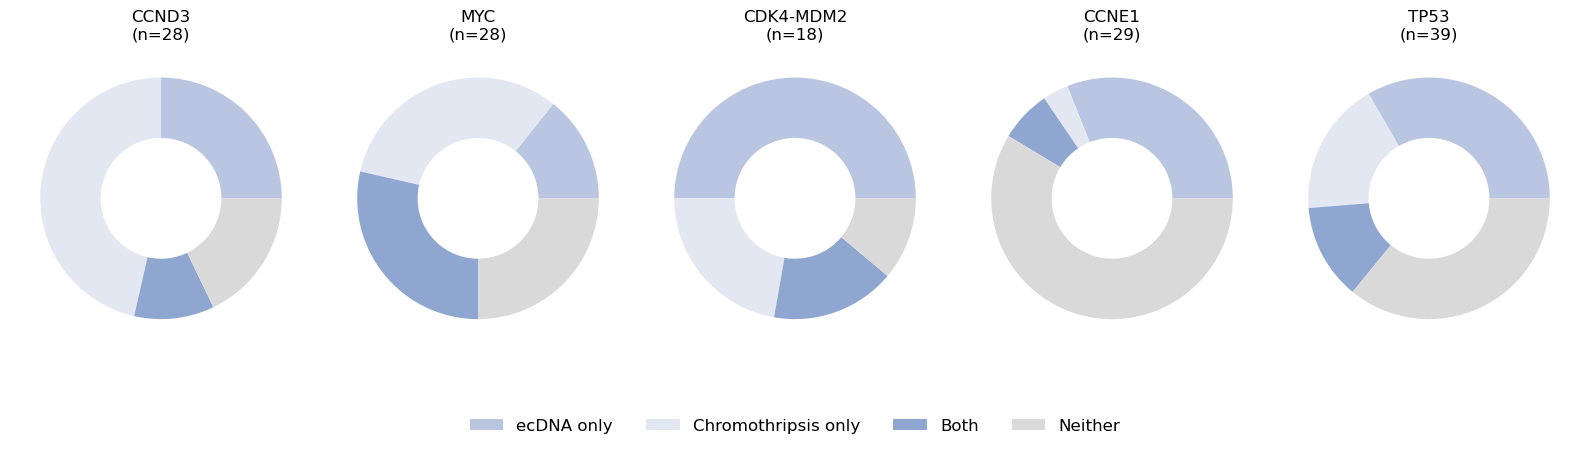

In [14]:
labels = ['ecDNA only', 'Chromothripsis only', 'Both', 'Neither']
colors = ['#bac6e1', '#e3e7f2', '#8fa6d0', '#d9d9d9']
color_map = dict(zip(labels, colors))

def make_autopct(total):
    def f(pct):
        count = int(round(pct / 100 * total))
        return f'{pct:.0f}%\n({count})'
    return f

fig, axes = plt.subplots(1, 5, figsize=(16, 5))

for ax, col in zip(axes, hotspot_cols):
    sub = matrix_base[matrix_base[col] > 0]
    n=len(sub)
    if len(sub) == 0:
        ax.set_visible(False)
        continue
    ec = sub[f'ecDNA_{col}'] > 0
    ct = sub[f'{col}_chromothripsis'] > 0
    sizes = [(ec & ~ct).sum(), (~ec & ct).sum(), (ec & ct).sum(), (~ec & ~ct).sum()]
    print(f'{col} (n={n})')
    for label, s in zip(labels, sizes):
        pct = 100 * s / n
        print(f'  {label:<20} {s:>4}  ({pct:5.1f}%)')
    print()
    non_zero = [(s, l) for s, l in zip(sizes, labels) if s > 0]
    if not non_zero:
        continue
    wedges, texts = ax.pie(
        sizes,
        labels=None,
        autopct=None,
        colors=[color_map[l] for l in labels],
        wedgeprops=dict(width=0.5)
    )
    ax.set_title(f'{col}\n(n={len(sub)})')

legend_elements = [Patch(facecolor=color_map[l], label=l) for l in labels]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0), frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

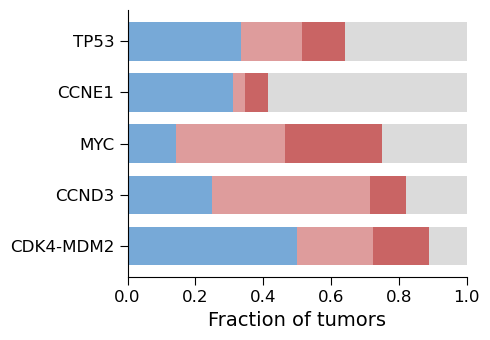

In [ ]:
# plot for manuscript
labels = ['ecDNA', 'Chromothripsis', 'ecDNA & Chromothripsis', 'Neither']
colors = ['#3d85c6ff', '#d17373ff', '#b22222ff', '#ccccccff']
color_map = dict(zip(labels, colors))

bar_data = {l: [] for l in labels}
bar_titles, bar_ns = [], []

for col in hotspot_cols:
    sub = matrix_base[matrix_base[col] > 0]
    if len(sub) == 0:
        continue
    ec = sub[f'ecDNA_{col}'] > 0
    ct = sub[f'{col}_chromothripsis'] > 0
    counts = {
        'ecDNA':                  (ec & ~ct).sum(),
        'Chromothripsis':         (~ec & ct).sum(),
        'ecDNA & Chromothripsis': (ec & ct).sum(),
        'Neither':                (~ec & ~ct).sum(),
    }
    for l in labels:
        bar_data[l].append(counts[l])
    bar_titles.append(col)
    bar_ns.append(len(sub))

# sort by total descending
order = np.argsort(bar_ns)[::-1]
bar_titles = [bar_titles[i] for i in order]
bar_ns     = [bar_ns[i] for i in order]
for l in labels:
    bar_data[l] = [bar_data[l][i] for i in order]

BAR_HEIGHT = 0.45
y = np.arange(len(bar_titles)) * 0.6
fig, ax = plt.subplots(figsize=(5, 3.5))
left = np.zeros(len(bar_titles), dtype=float)
for l in labels:
  vals = np.array(bar_data[l], dtype=float) / np.array(bar_ns, dtype=float)  # fraction per hotspot
  ax.barh(y, vals, left=left, color=color_map[l], label=l, height=BAR_HEIGHT, alpha=0.7)
  left += vals
ax.set_yticks(y)
ax.set_yticklabels(bar_titles, fontsize=12)
ax.set_xlabel('Fraction of tumors', fontsize=14)
ax.set_xlim(0, 1)
ticks = np.linspace(0, 1, 6)  # 0, 0.2, ..., 1.0
ax.set_xticks(ticks)
ax.set_xticklabels([f"{t:.1f}" for t in ticks], fontsize=12)

ax.tick_params(length=6)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../results/clustered_sv_chromothripsis_ecDNA_barplot.png', dpi=300)
plt.show()